Nome: Luís Fernando Silva Lima

RA: 298966

Curso: Engenharia Elétrica (Mestrado)



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais: 
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação. 

In [64]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import graycomatrix, graycoprops

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook. 

In [65]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [66]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

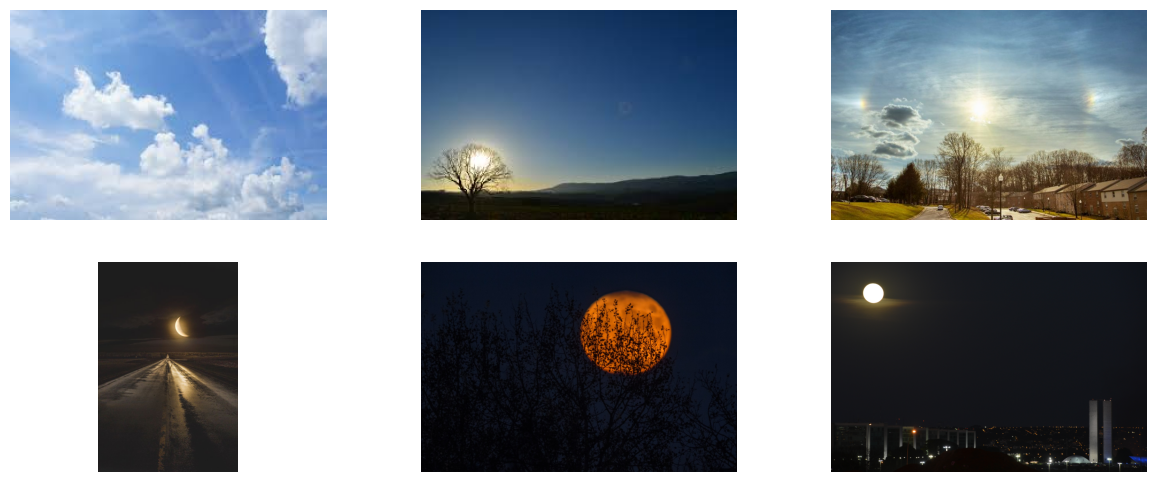

In [67]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:
  
  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))    
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

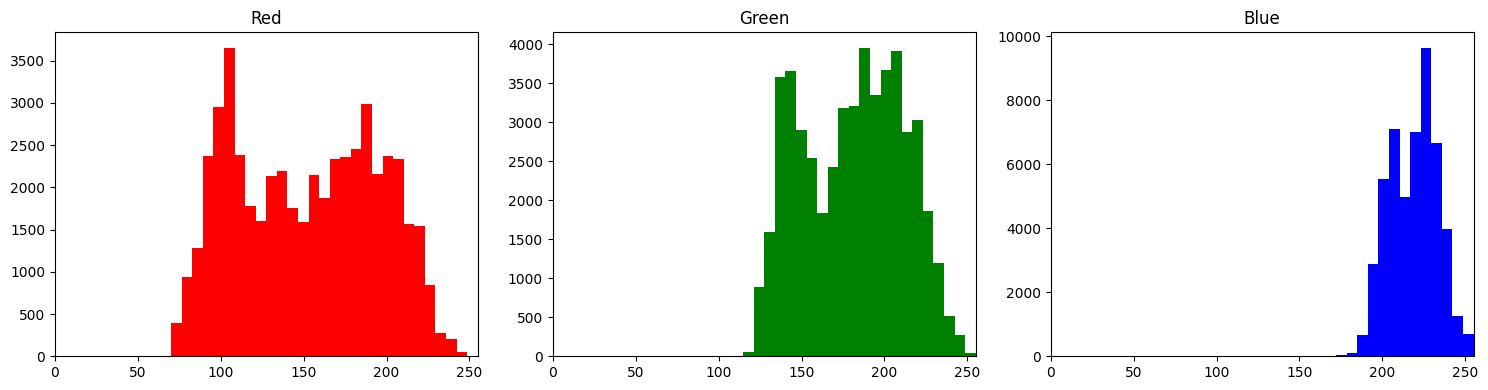

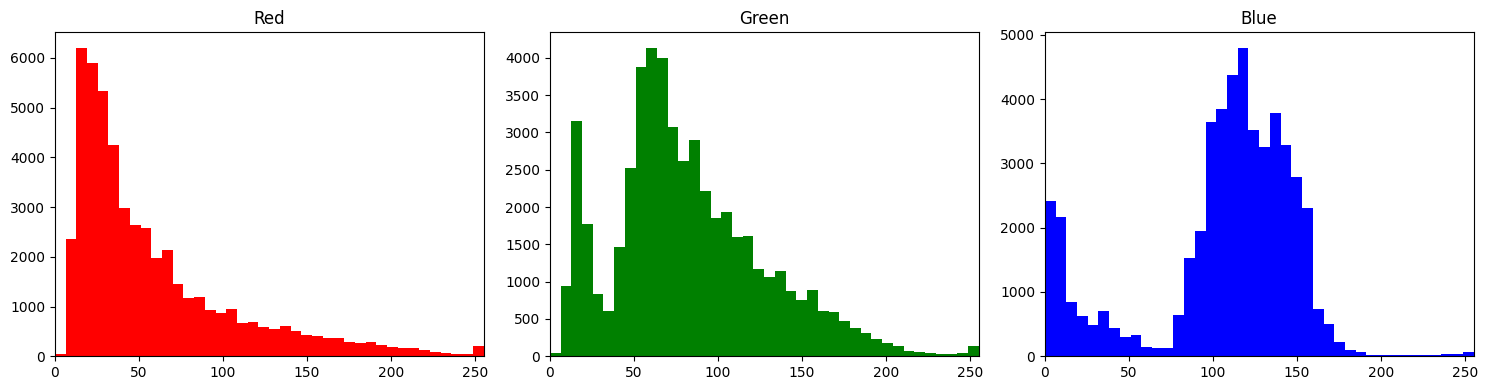

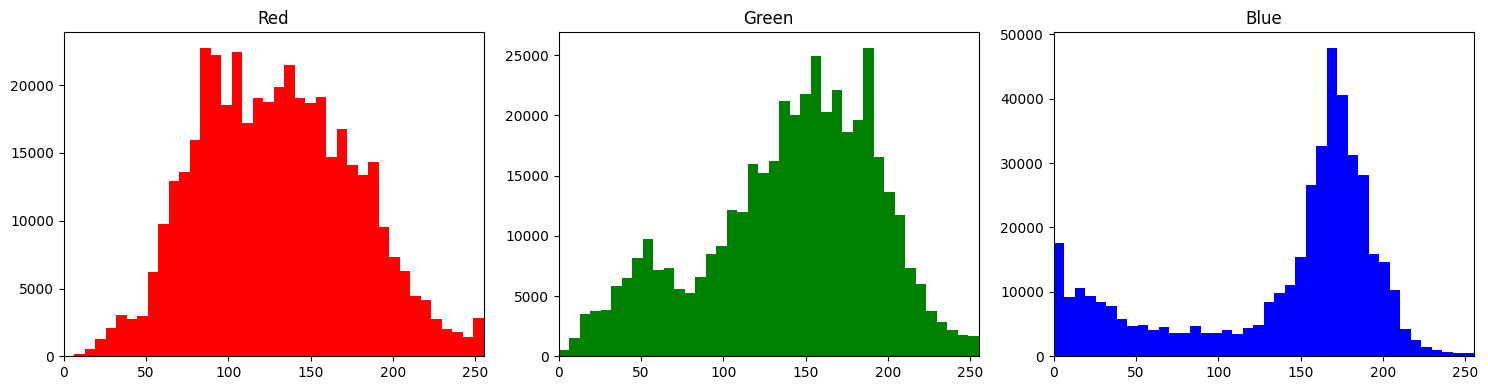

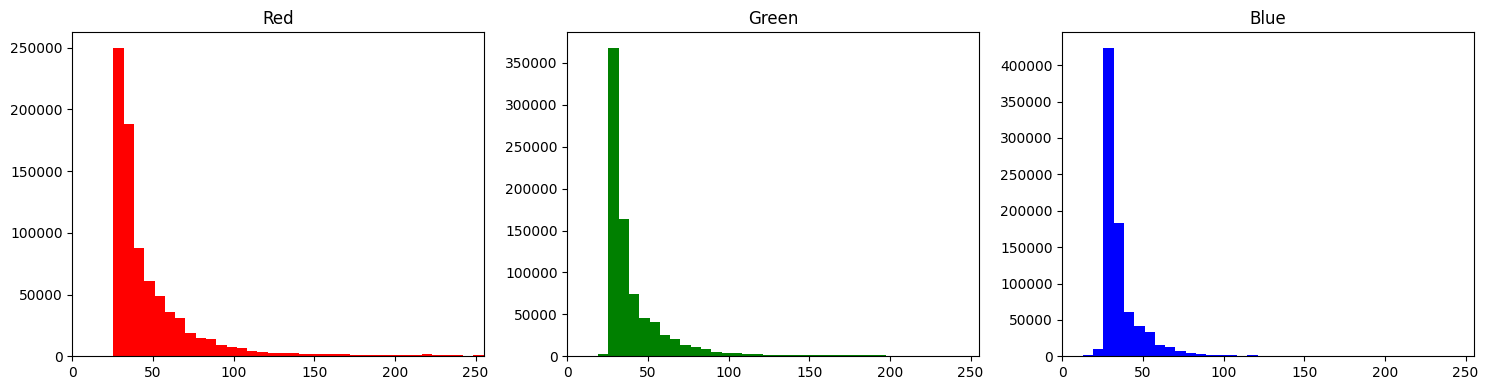

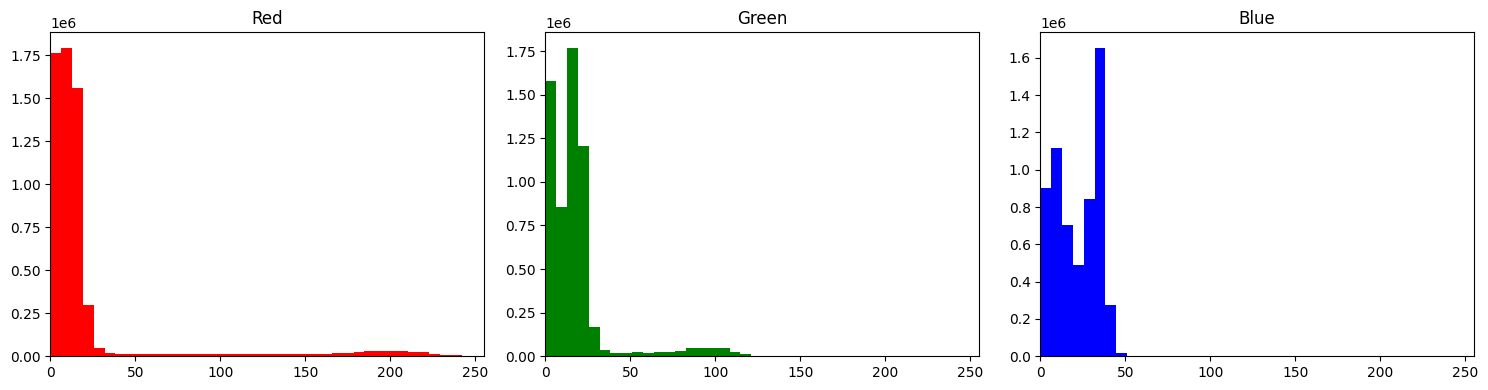

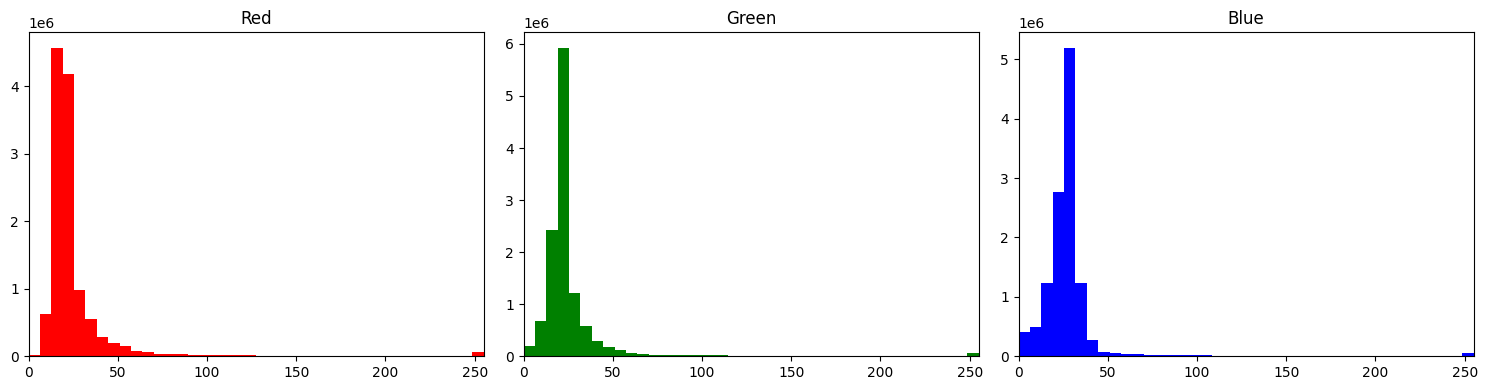

In [68]:
nbins = 40

for img in all_imgs:
    red = img[:, :, 0]
    green = img[:, :, 1]
    blue = img[:, :, 2]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    h, bin_edges = np.histogram(red, nbins,(0,255))
    plt.sca(axs[0]) 
    plota_hist(h, 'red', nbins, bin_edges)
    axs[0].set_title("Red")
    axs[0].set_xlim(0, 255)

    h, bin_edges = np.histogram(green, nbins,(0,255))
    plt.sca(axs[1]) 
    plota_hist(h, 'green', nbins, bin_edges)
    axs[1].set_title("Green")
    axs[1].set_xlim(0, 255)

    h, bin_edges = np.histogram(blue, nbins,(0,255))
    plt.sca(axs[2]) 
    plota_hist(h, 'blue', nbins, bin_edges)
    axs[2].set_title("Blue")
    axs[2].set_xlim(0, 255)

    plt.tight_layout()
    plt.show()

**Resposta:** Ao analisar os histogramas das imagens percebe-se que alguns são mais concentrados na parte esquerda do gráfico enquanto outros são mais distribuídos ou então mais direcionados na parte direita. Ao fazer a correspodência figura-histograma percebe-se que esse primeiro caso é justamente observado nas fotografias obtidas pela noite, o que era esperado já que há a predominância de cores escuras. Enquanto, a segunda circunstância é notado que são para as figuras mais claras retiradas na parte do dia, novamente isso era esperado já que são necessárias mais faixas de frequência para representar lugares iluminados, asssim, justificando a tendência no histograma de mostrar a utilização de imagens mais voltadas ao branco. Utilizando essas correspondências é possível fazer a inferência de qual imagem é dia e qual é noite.

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

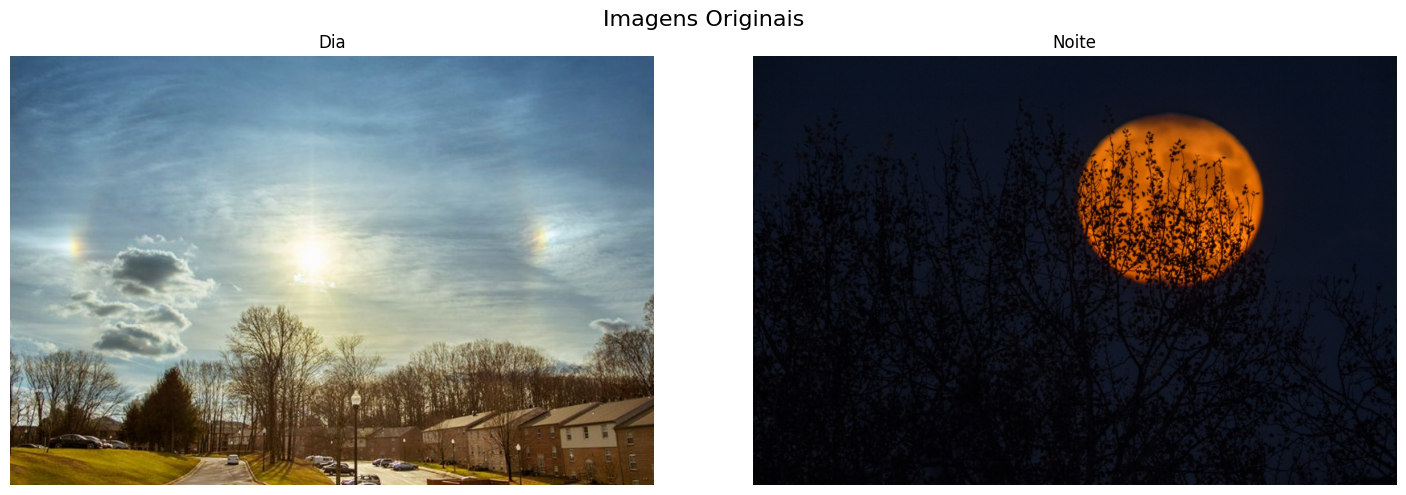

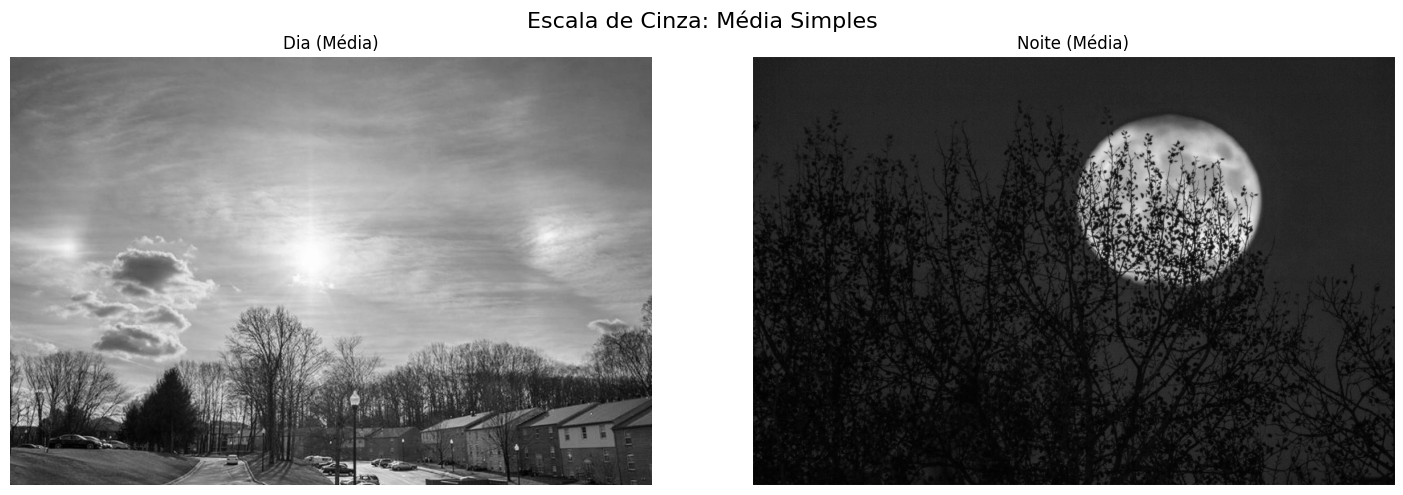

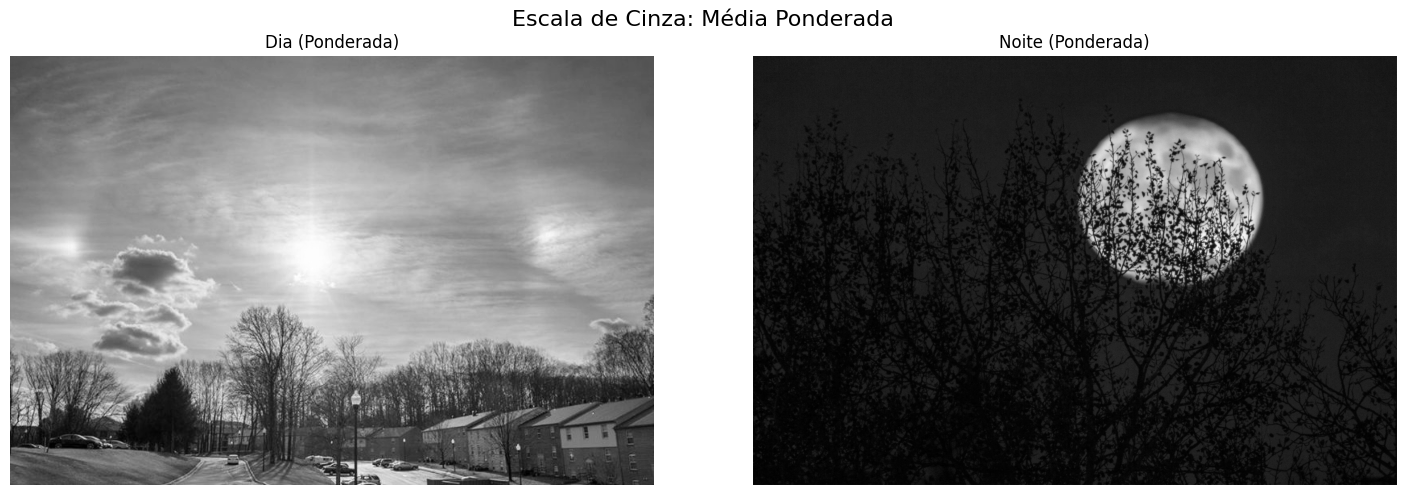

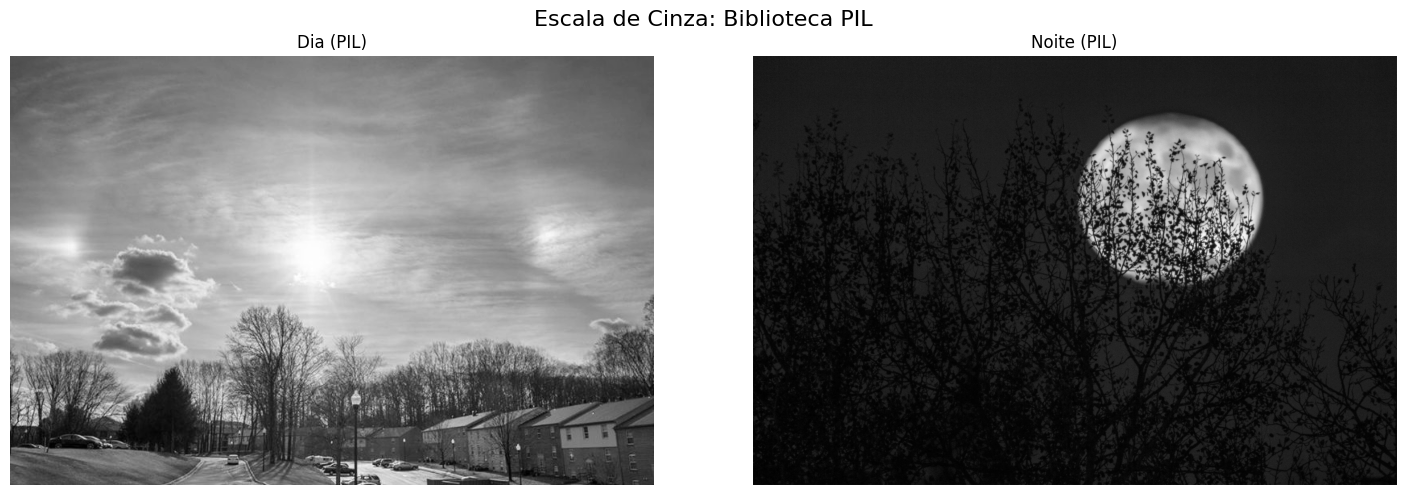

In [69]:
imagem_dia = all_imgs[2]
imagem_noite = all_imgs[4]

#obtendo as bandas de cada imagem
red_dia = imagem_dia[:, :, 0]
green_dia = imagem_dia[:, :, 1]
blue_dia = imagem_dia[:, :, 2]

red_noite = imagem_noite[:, :, 0]
green_noite = imagem_noite[:, :, 1]
blue_noite = imagem_noite[:, :, 2]

from PIL import Image

#IMAGENS ORIGINAIS
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Imagens Originais", fontsize=16)

axs[0].imshow(imagem_dia)
axs[0].set_title("Dia")
axs[0].axis('off')

axs[1].imshow(imagem_noite)
axs[1].set_title("Noite")
axs[1].axis('off')

plt.tight_layout()
plt.show()

#MÉDIA SIMPLES
gray_dia_simples = np.uint8((red_dia.astype(float) + green_dia.astype(float) + blue_dia.astype(float)) / 3)
gray_noite_simples = np.uint8((red_noite.astype(float) + green_noite.astype(float) + blue_noite.astype(float)) / 3)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Escala de Cinza: Média Simples", fontsize=16)

axs[0].imshow(gray_dia_simples, cmap='gray')
axs[0].set_title("Dia (Média)")
axs[0].axis('off')

axs[1].imshow(gray_noite_simples, cmap='gray')
axs[1].set_title("Noite (Média)")
axs[1].axis('off')

plt.tight_layout()
plt.show()

#MÉDIA PONDERADA
gray_dia_ponderada = np.uint8(0.299 * red_dia + 0.587 * green_dia + 0.114 * blue_dia)
gray_noite_ponderada = np.uint8(0.299 * red_noite + 0.587 * green_noite + 0.114 * blue_noite)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Escala de Cinza: Média Ponderada", fontsize=16)

axs[0].imshow(gray_dia_ponderada, cmap='gray')
axs[0].set_title("Dia (Ponderada)")
axs[0].axis('off')

axs[1].imshow(gray_noite_ponderada, cmap='gray')
axs[1].set_title("Noite (Ponderada)")
axs[1].axis('off')

plt.tight_layout()
plt.show()

#MÉTODO PIL
gray_pil_dia = Image.fromarray(imagem_dia).convert('L')
gray_pil_noite = Image.fromarray(imagem_noite).convert('L')

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Escala de Cinza: Biblioteca PIL", fontsize=16)

axs[0].imshow(gray_pil_dia, cmap='gray')
axs[0].set_title("Dia (PIL)")
axs[0].axis('off')

axs[1].imshow(gray_pil_noite, cmap='gray')
axs[1].set_title("Noite (PIL)")
axs[1].axis('off')

plt.tight_layout()
plt.show()

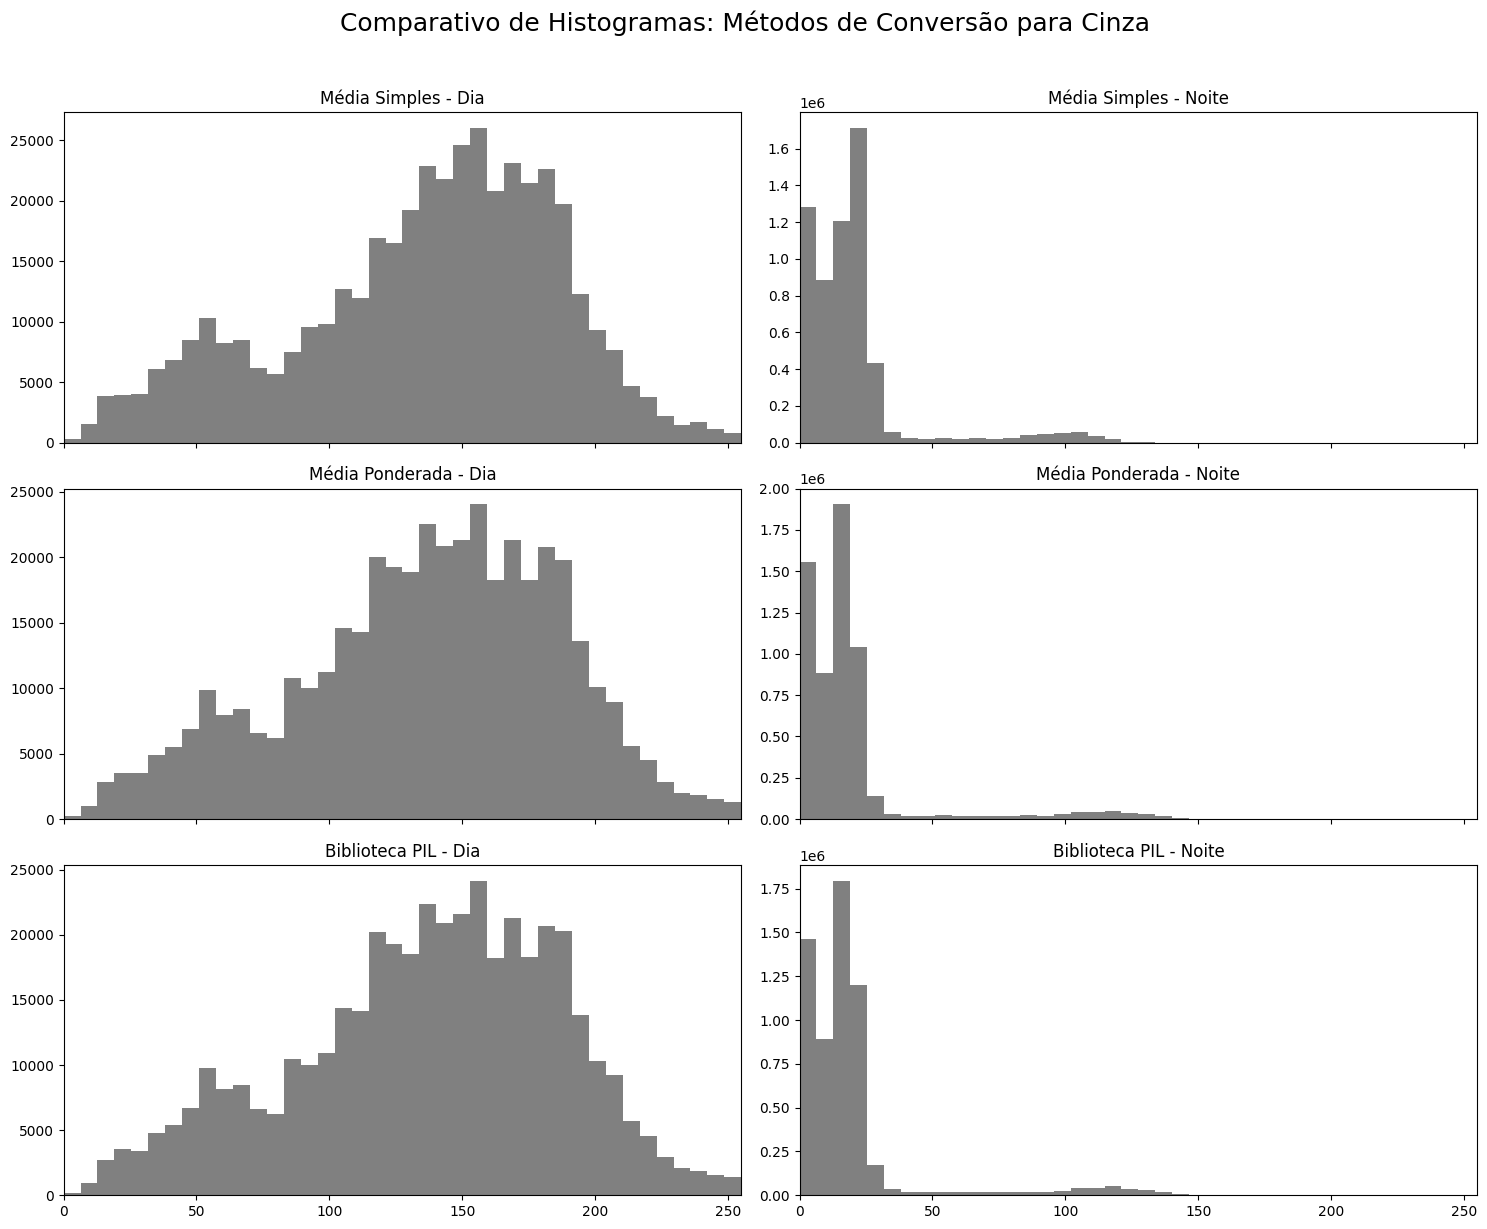

In [70]:
fig, axs = plt.subplots(3, 2, figsize=(15, 12), sharex=True)
fig.suptitle("Comparativo de Histogramas: Métodos de Conversão para Cinza", fontsize=18, y=1.02)

metodos = [
    ('Média Simples', gray_dia_simples, gray_noite_simples),
    ('Média Ponderada', gray_dia_ponderada, gray_noite_ponderada),
    ('Biblioteca PIL', np.array(gray_pil_dia), np.array(gray_pil_noite))
]

for i, (nome, img_dia, img_noite) in enumerate(metodos):
    h_dia, bin_dia = np.histogram(img_dia, nbins, (0, 255))
    plt.sca(axs[i, 0])
    plota_hist(h_dia, 'gray', nbins, bin_dia)
    axs[i, 0].set_title(f"{nome} - Dia")
    axs[i, 0].set_xlim(0, 255)
    
    h_noite, bin_noite = np.histogram(img_noite, nbins, (0, 255))
    plt.sca(axs[i, 1])
    plota_hist(h_noite, 'gray', nbins, bin_noite)
    axs[i, 1].set_title(f"{nome} - Noite")
    axs[i, 1].set_xlim(0, 255)

plt.tight_layout()
plt.show()


**Resposta:** Nesse caso, estava acontecendo algo estranho com a imagem de dia quando estava calculando a média simples, pois, o histograma parecia cortada aproximadamente no valor 100, após pesquisar vi que podia está ocorrendo overflow por causa da utilização do tipo uint8 (que vai até 255) e a soma provavelmente devia passar desse valor. Para solucionar converti para float que possibilitaria a representação do valor somado e o histograma ficou como o esperado. 
Agora analisando os histogramas percebe-se que os dois últimos são bem próximos demonstrando que provavelmente a biblioteca também utiliza média ponderada, porém a diferença talvez ocorra porque os valores são próximos mas diferentes. Enquanto, o da média simples também seja parecido, porém, a média enfatizando o verde melhora a percepção para os olhos humanos.

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens. 

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [71]:
def histstat(f):
    
    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [72]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [73]:
f_noite = all_imgs[4]
f_gray_noite = np.uint8(0.3*f_noite[:,:,0]+0.59*f_noite[:,:,1]+0.11*f_noite[:,:,2])

hist_features_noite = histstat(f_gray_noite)

print(f"Média Dia: {hist_features[0]:.2f} - Noite: {hist_features_noite[0]:.2f}")
print(f"Variância Dia: {hist_features[1]:.2f} - Noite: {hist_features_noite[1]:.2f}")
print(f"Skewness Dia: {hist_features[2]:.2f} - Noite: {hist_features_noite[2]:.2f}")
print(f"Kurtosis Dia: {hist_features[3]:.2f} - Noite: {hist_features_noite[3]:.2f}")
print(f"1% Percentil Dia: {hist_features[4]:.2f} - Noite: {hist_features_noite[4]:.2f}")
print(f"10% Percentil Dia: {hist_features[5]:.2f} - Noite: {hist_features_noite[5]:.2f}")
print(f"50% Percentil Dia: {hist_features[6]:.2f} - Noite: {hist_features_noite[6]:.2f}")
print(f"90% Percentil Dia: {hist_features[7]:.2f} - Noite: {hist_features_noite[7]:.2f}")
print(f"99% Percentil Dia: {hist_features[8]:.2f} - Noite: {hist_features_noite[8]:.2f}")

Média Dia: 175.75 - Noite: 19.05
Variância Dia: 1035.83 - Noite: 594.49
Skewness Dia: -0.03 - Noite: 3.25
Kurtosis Dia: -1.11 - Noite: 10.72
1% Percentil Dia: 118.00 - Noite: 0.00
10% Percentil Dia: 132.00 - Noite: 3.00
50% Percentil Dia: 178.00 - Noite: 15.00
90% Percentil Dia: 218.00 - Noite: 26.00
99% Percentil Dia: 237.00 - Noite: 128.00


**Resposta:** Analisando os atributos dos histogramas das imagens percebe-se que a média mostra que as imagens possuem características de brilho opostas, além disso, 90% da imagem noturna está abaixo de 26, enquanto 90% do dia está acima de 132, assim demonstrando que a imagem da noite está concentrada nos valores iniciais (mais escuros) e do dia está mais disposta entre os tons de cinza o que é comprovado pelos valores de variância. Ademais, o skewness de -0.03 indica uma distribuição simétrica e a kurtosis demonstra tons espalhados, assim, refletindo uma imagem de dia, e com a noite acontece o contrário, desta forma, facilitando a distinção entre as imagens.

## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors) 

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN: 

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

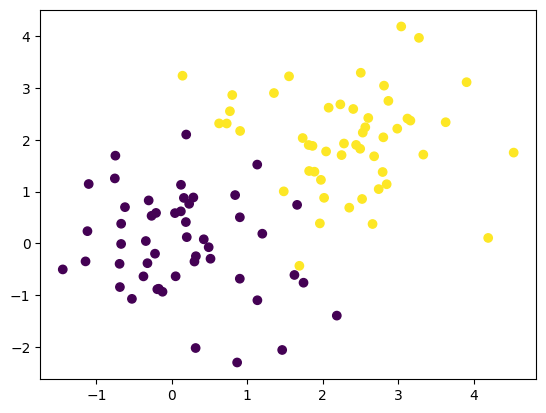

In [74]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las. 

A função *predict()* é utilizada para classificar as novas amostras.



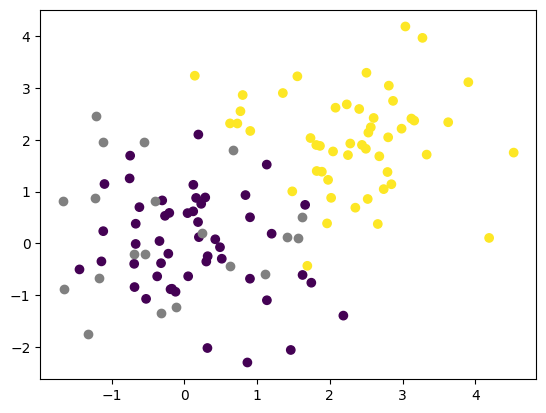

In [75]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [76]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


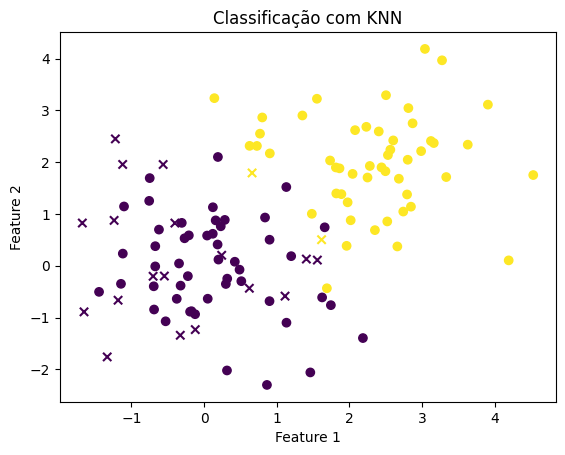

In [77]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [78]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [79]:
train_dataset = DermaMNIST(
    split="train",
    download=True 
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [80]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []
    
    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

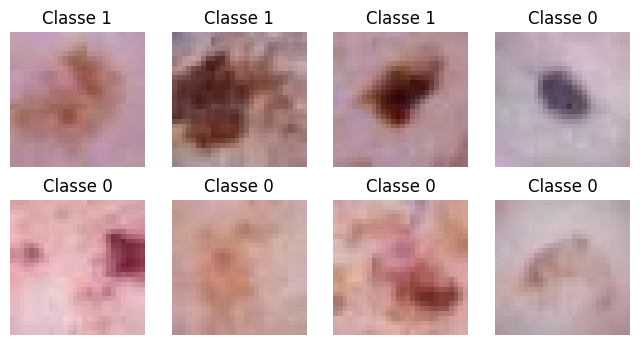

In [81]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features). 

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9. 

In [82]:
def extract_features(images):
    features = []
    for img in images:
        img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
        hist_features = histstat(img_gray)
        features.append(hist_features)
    return np.array(features)

X_train = extract_features(images_train)
X_test = extract_features(images_test)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

print(f'1º Amostra de X_train:\n{X_train[0]}')
print(f'1º Amostra de X_test:\n{X_test[0]}')

X_train shape: (400, 9)
X_test shape: (100, 9)
1º Amostra de X_train:
[191.12117347 779.12179658  -2.40539938   5.78497858  72.
 146.         202.         208.         213.        ]
1º Amostra de X_test:
[149.24489796 338.99359642  -0.39596495  -0.58713295 105.
 122.         152.         172.         182.        ]


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [83]:
#Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

#Treinando o modelo
model.fit(X_train, labels_train)

#Métricas de treino
train_pred = model.predict(X_train)
acc_train = accuracy_score(labels_train, train_pred)
prec_train = precision_score(labels_train, train_pred)
rec_train = recall_score(labels_train, train_pred)
f1_train = f1_score(labels_train, train_pred)
mc_train = confusion_matrix(labels_train, train_pred)

#Métricas de teste
test_pred = model.predict(X_test)
acc_test = accuracy_score(labels_test, test_pred)
prec_test = precision_score(labels_test, test_pred)
rec_test = recall_score(labels_test, test_pred)
f1_test = f1_score(labels_test, test_pred)
mc_test = confusion_matrix(labels_test, test_pred)

print('--- Treino ---')
print('Acurácia: %.2f' % acc_train)
print('Precisão: %.2f' % prec_train)
print('Recall: %.2f' % rec_train)
print('F1-Score: %.2f' % f1_train)
print('Matriz de Confusão:')
print(mc_train)

print('\n--- Teste ---')
print('Acurácia: %.2f' % acc_test)
print('Precisão: %.2f' % prec_test)
print('Recall: %.2f' % rec_test)
print('F1-Score: %.2f' % f1_test)
print('Matriz de Confusão:')
print(mc_test)

--- Treino ---
Acurácia: 0.82
Precisão: 0.79
Recall: 0.88
F1-Score: 0.83
Matriz de Confusão:
[[154  46]
 [ 24 176]]

--- Teste ---
Acurácia: 0.81
Precisão: 0.77
Recall: 0.88
F1-Score: 0.82
Matriz de Confusão:
[[37 13]
 [ 6 44]]


**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

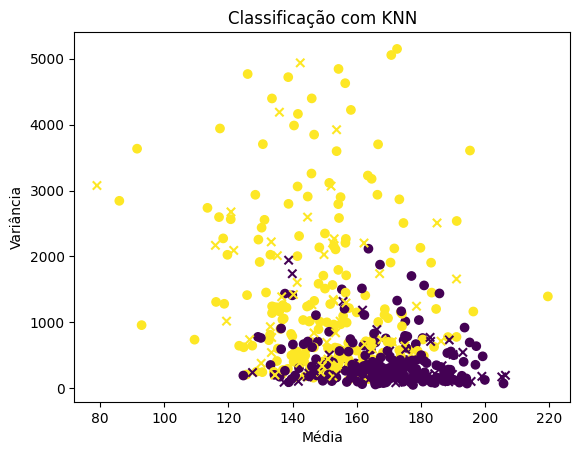

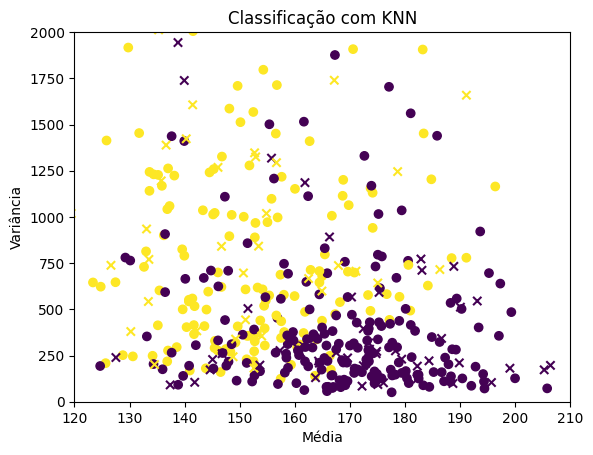

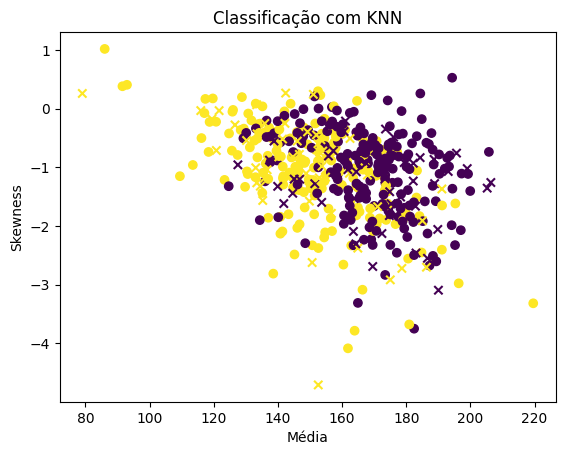

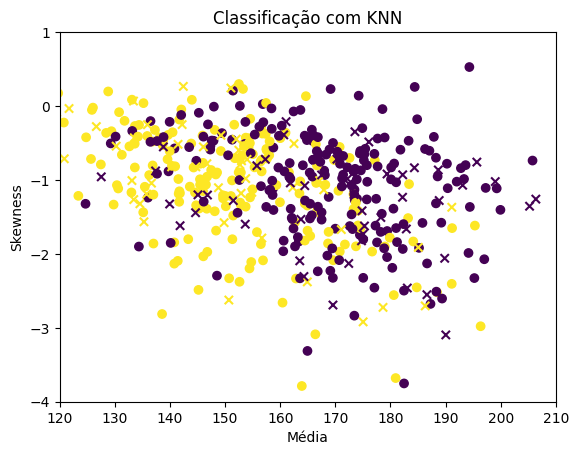

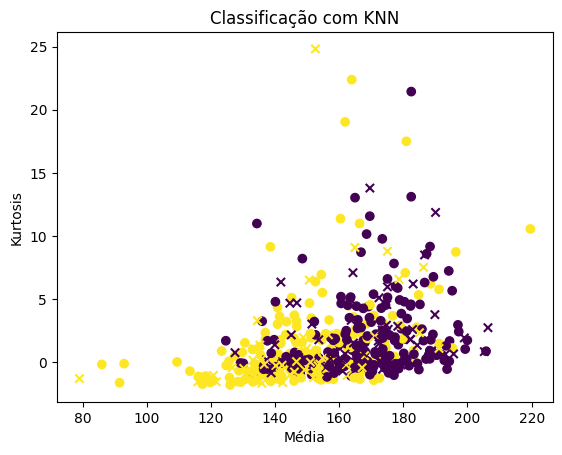

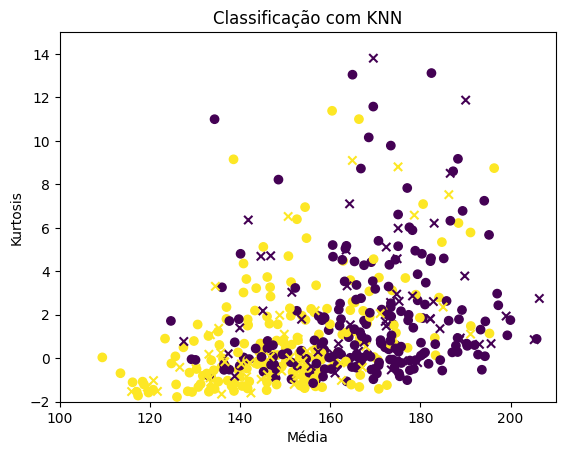

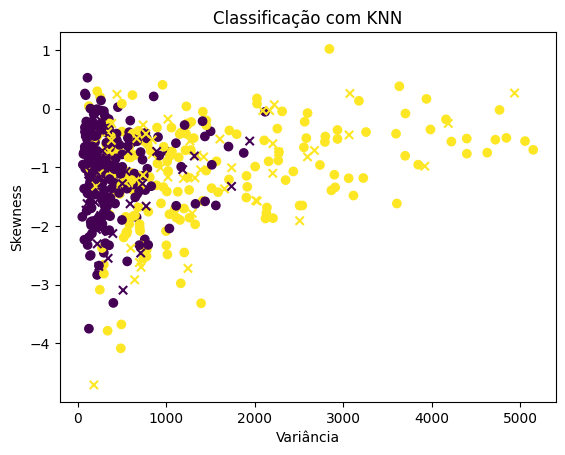

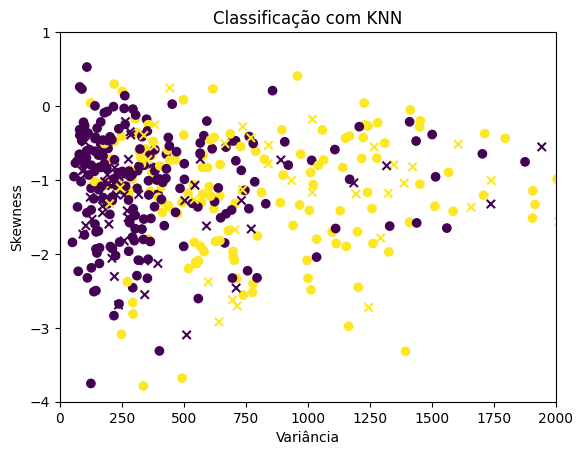

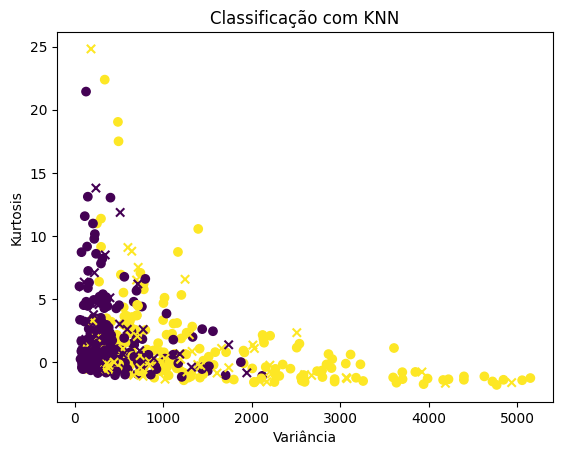

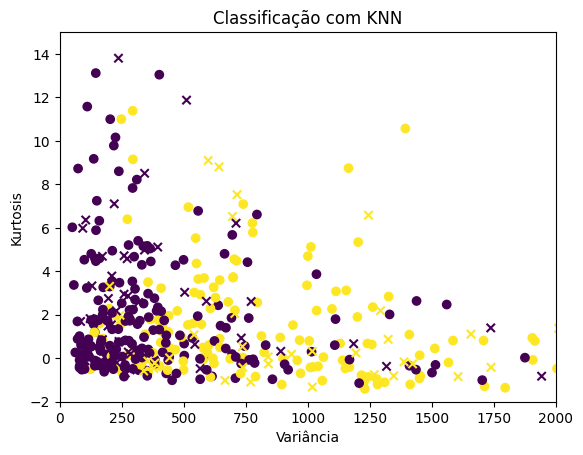

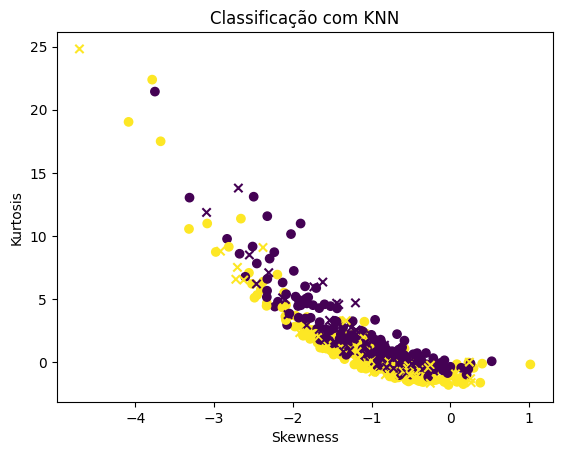

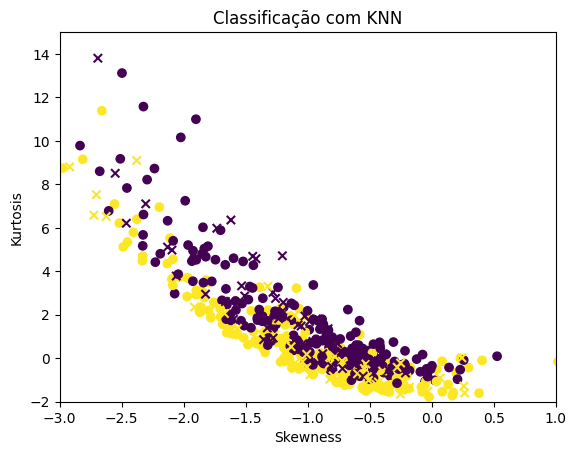

In [84]:
#Plotando os resultados
plt.scatter(X_train[:, 0], X_train[:, 1], c=labels_train)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Média')
plt.ylabel('Variância')
plt.show()

#Dando um zoom para observar melhor as predições nas fronteiras entre as classes
plt.xlim(120, 210)
plt.ylim(0, 2000)
plt.scatter(X_train[:, 0], X_train[:, 1], c=labels_train)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Média')
plt.ylabel('Variância')
plt.show()



#Plotando os resultados
plt.scatter(X_train[:, 0], X_train[:, 2], c=labels_train)
plt.scatter(X_test[:, 0], X_test[:, 2], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Média')
plt.ylabel('Skewness')
plt.show()

#Dando um zoom para observar melhor as predições nas fronteiras entre as classes
plt.xlim(120, 210)
plt.ylim(-4, 1)
plt.scatter(X_train[:, 0], X_train[:, 2], c=labels_train)
plt.scatter(X_test[:, 0], X_test[:, 2], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Média')
plt.ylabel('Skewness')
plt.show()



#Plotando os resultados
plt.scatter(X_train[:, 0], X_train[:, 3], c=labels_train)
plt.scatter(X_test[:, 0], X_test[:, 3], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Média')
plt.ylabel('Kurtosis')
plt.show()

#Dando um zoom para observar melhor as predições nas fronteiras entre as classes
plt.xlim(100, 210)
plt.ylim(-2, 15)
plt.scatter(X_train[:, 0], X_train[:, 3], c=labels_train)
plt.scatter(X_test[:, 0], X_test[:, 3], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Média')
plt.ylabel('Kurtosis')
plt.show()



#Plotando os resultados
plt.scatter(X_train[:, 1], X_train[:, 2], c=labels_train)
plt.scatter(X_test[:, 1], X_test[:, 2], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Variância')
plt.ylabel('Skewness')
plt.show()

#Dando um zoom para observar melhor as predições nas fronteiras entre as classes
plt.xlim(0, 2000)
plt.ylim(-4, 1)
plt.scatter(X_train[:, 1], X_train[:, 2], c=labels_train)
plt.scatter(X_test[:, 1], X_test[:, 2], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Variância')
plt.ylabel('Skewness')
plt.show()



#Plotando os resultados
plt.scatter(X_train[:, 1], X_train[:, 3], c=labels_train)
plt.scatter(X_test[:, 1], X_test[:, 3], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Variância')
plt.ylabel('Kurtosis')
plt.show()

#Dando um zoom para observar melhor as predições nas fronteiras entre as classes
plt.xlim(0, 2000)
plt.ylim(-2, 15)
plt.scatter(X_train[:, 1], X_train[:, 3], c=labels_train)
plt.scatter(X_test[:, 1], X_test[:, 3], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Variância')
plt.ylabel('Kurtosis')
plt.show()



#Plotando os resultados
plt.scatter(X_train[:, 2], X_train[:, 3], c=labels_train)
plt.scatter(X_test[:, 2], X_test[:, 3], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Skewness')
plt.ylabel('Kurtosis')
plt.show()

#Dando um zoom para observar melhor as predições nas fronteiras entre as classes
plt.xlim(-3, 1)
plt.ylim(-2, 15)
plt.scatter(X_train[:, 2], X_train[:, 3], c=labels_train)
plt.scatter(X_test[:, 2], X_test[:, 3], marker='x', c=labels_test)
plt.title('Classificação com KNN')
plt.xlabel('Skewness')
plt.ylabel('Kurtosis')
plt.show()

**Resposta:** Como era solicitado plota os atributos de 2 em 2 optei por considerar apenas média, variância, skewness e kurtosis, pois, considerar os percentis aumentaria bastante o número de gráficos para análise. Com base nesses gráficos é notório que realmente as duas classes estão divididas, porém na fronteira elas são mais "misturadas" o que justifica a precisão do classificador não está mais alta mesmo assim ele conseguiu classificar os dados.

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

**Resposta:** Gostei do resultado apesar de saber que não é suficiente considerando que é um problema que aborda a área médica, porém, há a proximidade entre os resultados de treino e teste indicando que o classificador possui uma boa capacidade de generalização, além disso, o erro mais frequente é o falso positivo, como mostram os 13 erros na matriz de confusão do teste isso é refletido uma precisão (0.77) menor que o recall (0.88), sugerindo que imagens de melanoma com tons mais escuros possuem médias e variâncias que confundem o KNN, fazendo-o acreditar que são carcinoma basocelular. Uma modificação seria normalizar e considerar as outras bandas da imagem.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

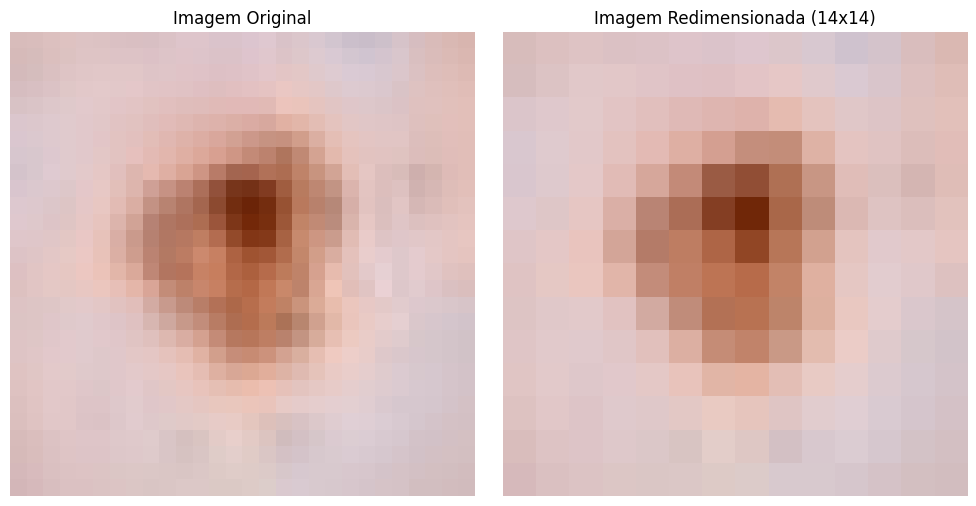

--- Treino ---
Acurácia: 0.81
Precisão: 0.82
Recall: 0.80
F1-Score: 0.81
Matriz de Confusão:
[[165  35]
 [ 40 160]]

--- Teste ---
Acurácia: 0.82
Precisão: 0.81
Recall: 0.84
F1-Score: 0.82
Matriz de Confusão:
[[40 10]
 [ 8 42]]


In [85]:
images_train_resized = []
for img in images_train:
    pil_img = Image.fromarray(img)
    resized_img = pil_img.resize((14, 14))
    images_train_resized.append(np.array(resized_img))

images_test_resized = []
for img in images_test:
    pil_img = Image.fromarray(img)
    resized_img = pil_img.resize((14, 14))
    images_test_resized.append(np.array(resized_img))

#Obtendo as características dos histogramas das imagens redimensionadas em escala de cinza
X_train_resized = extract_features(images_train_resized)
X_test_resized = extract_features(images_test_resized)

#Plotando a primeira imagem do dataset de treinamento antes e depois do redimensionamento
original_img = images_train[0]
resized_img = images_train_resized[0]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(original_img)
axs[0].set_title('Imagem Original')
axs[0].axis('off')

axs[1].imshow(resized_img)
axs[1].set_title('Imagem Redimensionada (14x14)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

from sklearn.feature_selection import VarianceThreshold

#Selecionando características com variância maior que 0.05
selector = VarianceThreshold(threshold=0.05)
X_train_resized_new = selector.fit_transform(X_train_resized)
X_test_resized_new = selector.transform(X_test_resized)

#Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=8)

#Treinando o modelo
model.fit(X_train_resized_new, labels_train)

#Métricas de treino
train_pred = model.predict(X_train_resized_new)
acc_train = accuracy_score(labels_train, train_pred)
prec_train = precision_score(labels_train, train_pred)
rec_train = recall_score(labels_train, train_pred)
f1_train = f1_score(labels_train, train_pred)
mc_train = confusion_matrix(labels_train, train_pred)

#Métricas de teste
test_pred = model.predict(X_test_resized_new)
acc_test = accuracy_score(labels_test, test_pred)
prec_test = precision_score(labels_test, test_pred)
rec_test = recall_score(labels_test, test_pred)
f1_test = f1_score(labels_test, test_pred)
mc_test = confusion_matrix(labels_test, test_pred)
 
print('--- Treino ---')
print('Acurácia: %.2f' % acc_train)
print('Precisão: %.2f' % prec_train)
print('Recall: %.2f' % rec_train)
print('F1-Score: %.2f' % f1_train)
print('Matriz de Confusão:')
print(mc_train)

print('\n--- Teste ---')
print('Acurácia: %.2f' % acc_test)
print('Precisão: %.2f' % prec_test)
print('Recall: %.2f' % rec_test)
print('F1-Score: %.2f' % f1_test)
print('Matriz de Confusão:')
print(mc_test)

**Resposta:** Desta vez os resultados melhoraram em relação ao classificador anterior, porém, não tanto.

## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

In [86]:
for name, chan in [('Red', 0), ('Green', 1), ('Blue', 2)]:
    #Utilizando as mesmas imagens redimensionadas
    X_train_chan = np.array([histstat(img[:, :, chan]) for img in images_train_resized])
    X_test_chan = np.array([histstat(img[:, :, chan]) for img in images_test_resized])

    sel = VarianceThreshold(threshold=0.05)
    X_train_c_sel = sel.fit_transform(X_train_chan)
    X_test_c_sel = sel.transform(X_test_chan)

    model_chan = KNeighborsClassifier(n_neighbors=8)
    model_chan.fit(X_train_c_sel, labels_train)

    acc = accuracy_score(labels_test, model_chan.predict(X_test_c_sel))
    prec = precision_score(labels_test, model_chan.predict(X_test_c_sel))
    rec = recall_score(labels_test, model_chan.predict(X_test_c_sel))
    f1 = f1_score(labels_test, model_chan.predict(X_test_c_sel))
    mc = confusion_matrix(labels_test, model_chan.predict(X_test_c_sel))

    print(f"\n=== Resultados (canal {name}) ===")
    print('Acurácia: %.2f' % acc)
    print('Precisão: %.2f' % prec)
    print('Recall: %.2f' % rec)
    print('F1-Score: %.2f' % f1)
    print('Matriz de Confusão:')
    print(mc)


=== Resultados (canal Red) ===
Acurácia: 0.76
Precisão: 0.75
Recall: 0.78
F1-Score: 0.76
Matriz de Confusão:
[[37 13]
 [11 39]]

=== Resultados (canal Green) ===
Acurácia: 0.80
Precisão: 0.81
Recall: 0.78
F1-Score: 0.80
Matriz de Confusão:
[[41  9]
 [11 39]]

=== Resultados (canal Blue) ===
Acurácia: 0.83
Precisão: 0.84
Recall: 0.82
F1-Score: 0.83
Matriz de Confusão:
[[42  8]
 [ 9 41]]


**Resposta:** #Para a extração dos atributos coloridos foi utilizada a mesma função histstat definida anteriormente, mas aplicada diretamente às bandas RGB sem converter para escala de cinza. Os atributos de cada canal foram concatenados, resultando em um total de 27 atributos (9 por canal) e depois avaliados cada um por vez. O canal azul apresentou os melhores resultados, seguido pelo verde e vermelho. Isso pode ser explicado pelo fato de que as imagens de melanoma e carcinoma podem apresentar diferenças mais acentuadas na intensidade dos pixels azuis, o que torna esse canal mais discriminativo para a classificação. O canal verde também pode conter informações relevantes, mas o vermelho tende a ser menos informativo também porque várias das peles observadas são mais rosadas o que se reflete na menor relevância do canal vermelho. Além disso, o canal azul se saiu melhor que a escala de cinza, demonstrando a importância das cores nesse caso.

## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [90]:
#Função para extrair características GLCM das imagens
def extract_glcm_features(images):
    features = []
    for img in images:
        img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
        #Calcula o GLCM
        glcm = graycomatrix(img_gray, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)
        #Extrai as propriedades do GLCM
        contrast = graycoprops(glcm, 'contrast').mean()
        dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
        homogeneity = graycoprops(glcm, 'homogeneity').mean()
        energy = graycoprops(glcm, 'energy').mean()
        correlation = graycoprops(glcm, 'correlation').mean()
        features.append([contrast, dissimilarity, homogeneity, energy, correlation])
    return np.array(features)

#Usando as imagens redimensionadas para extrair as características GLCM
X_train_glcm = extract_glcm_features(images_train_resized)
X_test_glcm = extract_glcm_features(images_test_resized)

print(f'X_train_glcm shape: {X_train_glcm.shape}')
print(f'X_test_glcm shape: {X_test_glcm.shape}')

model_glcm = KNeighborsClassifier(n_neighbors=5)
model_glcm.fit(X_train_glcm, labels_train)

train_pred_glcm = model_glcm.predict(X_train_glcm)
acc_train_glcm = accuracy_score(labels_train, train_pred_glcm)
prec_train_glcm = precision_score(labels_train, train_pred_glcm)
rec_train_glcm = recall_score(labels_train, train_pred_glcm)
f1_train_glcm = f1_score(labels_train, train_pred_glcm)
mc_train_glcm = confusion_matrix(labels_train, train_pred_glcm)

test_pred_glcm = model_glcm.predict(X_test_glcm)
acc_test_glcm = accuracy_score(labels_test, test_pred_glcm)
prec_test_glcm = precision_score(labels_test, test_pred_glcm)
rec_test_glcm = recall_score(labels_test, test_pred_glcm)
f1_test_glcm = f1_score(labels_test, test_pred_glcm)
mc_test_glcm = confusion_matrix(labels_test, test_pred_glcm)

print('--- Treino (GLCM) ---')
print('Acurácia: %.2f' % acc_train_glcm)
print('Precisão: %.2f' % prec_train_glcm)
print('Recall: %.2f' % rec_train_glcm)
print('F1-Score: %.2f' % f1_train_glcm)
print('Matriz de Confusão:')
print(mc_train_glcm)

print('\n--- Teste (GLCM) ---')
print('Acurácia: %.2f' % acc_test_glcm)
print('Precisão: %.2f' % prec_test_glcm)
print('Recall: %.2f' % rec_test_glcm)
print('F1-Score: %.2f' % f1_test_glcm)
print('Matriz de Confusão:')
print(mc_test_glcm)

X_train_glcm shape: (400, 5)
X_test_glcm shape: (100, 5)
--- Treino (GLCM) ---
Acurácia: 0.81
Precisão: 0.80
Recall: 0.83
F1-Score: 0.81
Matriz de Confusão:
[[158  42]
 [ 34 166]]

--- Teste (GLCM) ---
Acurácia: 0.75
Precisão: 0.74
Recall: 0.78
F1-Score: 0.76
Matriz de Confusão:
[[36 14]
 [11 39]]


**Resposta:** O método escolhido foi o GLCM, que é uma técnica de extração de atributos de textura baseada na análise da ocorrência de níveis de cinza em uma imagem. Funciona calculando uma matriz que representa a frequência com que pares de pixels com determinados valores de intensidade ocorrem em posições relativas específicas na imagem. Os parâmetros principais são as distâncias entre os pares de pixels e os ângulos de direção para capturar texturas em diferentes direções, o número de níveis de cinza, 256, se a matriz é simétrica e normalizada. Os atributos extraídos foram o contraste, dissimilaridade, homogeneidade, energia e correlação. Os resultados obtidos com GLCM foram inferiores aos dos atributos de histograma, com acurácia de teste em torno de 0.75, indicando que os atributos de histograma capturam melhor as diferenças entre carcinoma e melanoma nesse dataset em específico.